# IDX Next-Day Price Direction Prediction

## Phase 1: Setup & Data Acquisition

**Goal**: Predict whether a stock's closing price on day `t+1` will be higher or lower than on day `t` using only historical OHLCV data up to day `t`.

**Dataset**: `eren2222/complete-indonesia-stock-exchange-idx-2000-2024` from Kaggle

**Target**: Binary classification
- `1` = Close(t+1) > Close(t) — Price goes **Up**
- `0` = Close(t+1) <= Close(t) — Price goes **Down or Flat**

Constraints: Prevent data leakage!! features derived exclusively from data prior to day `t`.

In [1]:
pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Adra Prakoso\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# =============================================================================
# imports and config
# =============================================================================
import os
import sys
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Suppress warnings for cleaner output during exploration
warnings.filterwarnings('ignore')

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# kagglehub for portability
import kagglehub

DATA_DIR = kagglehub.dataset_download(
    "eren2222/complete-indonesia-stock-exchange-idx-2000-2024"
)
DATA_PATH = os.path.join(DATA_DIR, "IDX 2000-2024.csv")

# Project scope: only 2020–2024 per GOAL.md
START_DATE = "2020-01-01"
END_DATE   = "2024-12-31"

print("=" * 70)
print("IDX NEXT-DAY PRICE DIRECTION PREDICTION")
print("=" * 70)
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__}, NumPy: {np.__version__}")
print(f"Date range: {START_DATE} to {END_DATE}")
print("=" * 70)

IDX NEXT-DAY PRICE DIRECTION PREDICTION
Timestamp: 2026-05-19 21:34:42
Python: 3.13.13
Pandas: 3.0.1, NumPy: 2.4.3
Date range: 2020-01-01 to 2024-12-31


In [3]:
# The dataset has been pre-downloaded via kagglehub.
# If you need to re-download, uncomment the code below:

# import kagglehub
# download_path = kagglehub.dataset_download("eren2222/complete-indonesia-stock-exchange-idx-2000-2024")
# print("Downloaded to:", download_path)

# Verify the data file exists
if os.path.exists(DATA_PATH):
    file_size_gb = os.path.getsize(DATA_PATH) / (1024 ** 3)
    print(f"✓ Data file found: {DATA_PATH}")
    print(f"  File size: {file_size_gb:.2f} GB")
else:
    print(f"✗ Data file NOT found at: {DATA_PATH}")
    print("Please download the dataset first using kagglehub.")

✓ Data file found: C:\Users\Adra Prakoso\.cache\kagglehub\datasets\eren2222\complete-indonesia-stock-exchange-idx-2000-2024\versions\3\IDX 2000-2024.csv
  File size: 0.15 GB


In [4]:
# inspect column names and data types
df_preview = pd.read_csv(DATA_PATH, nrows=10)

print("Column Names:")
print(df_preview.columns.tolist())
print("\nData Types:")
print(df_preview.dtypes)
print("\nFirst 5 rows:")
print(df_preview.head())

Column Names:
['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Data Types:
Date             str
Ticker           str
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

First 5 rows:
         Date Ticker        Open        High         Low       Close  \
0  2001-04-05   AALI  571.710632  571.710632  547.889343  547.889343   
1  2001-04-06   AALI  547.889343  547.889343  547.889343  547.889343   
2  2001-04-09   AALI  547.889343  547.889343  547.889343  547.889343   
3  2001-04-10   AALI  547.889343  547.889343  547.889343  547.889343   
4  2001-04-11   AALI  547.889343  547.889343  547.889343  547.889343   

    Adj Close  Volume  
0  248.808121   57721  
1  248.808121   83433  
2  248.808121   10494  
3  248.808121  352625  
4  248.808121   59295  


In [5]:
# ds scaling; high level stats (2020–2024)
# to handle large files, read in chunks for aggregation

CHUNK_SIZE = 500_000  # rows per chunk

total_rows = 0
unique_tickers = set()
all_dates = []
chunk_count = 0

print("Reading dataset in chunks for 2020–2024...")
for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE, usecols=['Date', 'Ticker']):
    chunk['Date'] = pd.to_datetime(chunk['Date'])
    mask = (chunk['Date'] >= START_DATE) & (chunk['Date'] <= END_DATE)
    chunk = chunk[mask]
    if len(chunk) == 0:
        continue
    total_rows += len(chunk)
    unique_tickers.update(chunk['Ticker'].unique())
    all_dates.extend([chunk['Date'].iloc[0], chunk['Date'].iloc[-1]])
    chunk_count += 1
    if chunk_count % 5 == 0:
        print(f"  Processed {chunk_count} chunks... {total_rows:,} rows so far")

print("\n" + "=" * 70)
print("DATASET SCALE OVERVIEW (2020–2024)")
print("=" * 70)
print(f"Total rows:              {total_rows:,}")
print(f"Unique tickers:          {len(unique_tickers):,}")
print(f"Date range:              {min(all_dates).date()} to {max(all_dates).date()}")
print(f"Approx. rows per ticker: {total_rows / len(unique_tickers):,.0f}" if len(unique_tickers) > 0 else "N/A")
print(f"Total chunks read:       {chunk_count}")
print("=" * 70)

Reading dataset in chunks for 2020–2024...
  Processed 5 chunks... 787,827 rows so far

DATASET SCALE OVERVIEW (2020–2024)
Total rows:              833,488
Unique tickers:          931
Date range:              2020-01-02 to 2024-05-17
Approx. rows per ticker: 895
Total chunks read:       6


In [6]:
# =============================================================================
# Identify and Filter Suspended/Delisted Stocks
# =============================================================================
# Tickers with flat Close price (std == 0) across 2020-2024 are suspended
# or delisted. They provide zero predictive signal and must be excluded.
# This runs once so all downstream cells use only valid tickers.

from collections import defaultdict

print("Scanning all tickers for price/volume quality (2020-2024)...")

close_vals = defaultdict(list)
volume_totals = defaultdict(float)
row_counts = defaultdict(int)

for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE,
                         usecols=['Date', 'Ticker', 'Close', 'Volume']):
    chunk['Date'] = pd.to_datetime(chunk['Date'])
    mask = (chunk['Date'] >= START_DATE) & (chunk['Date'] <= END_DATE)
    chunk = chunk[mask]
    if len(chunk) == 0:
        continue
    for ticker in chunk['Ticker'].unique():
        sub = chunk[chunk['Ticker'] == ticker]
        close_vals[ticker].append(sub['Close'].values)
        volume_totals[ticker] += sub['Volume'].sum()
        row_counts[ticker] += len(sub)

# compute quality metrics per ticker
quality_rows = []
for ticker in close_vals:
    all_close = np.concatenate(close_vals[ticker])
    c_std = np.nanstd(all_close)
    c_mean = np.nanmean(all_close)
    v_tot = volume_totals[ticker]
    n = row_counts[ticker]
    is_suspended = (c_std == 0.0) or np.isnan(c_std)
    quality_rows.append({
        'ticker': ticker,
        'n_rows': n,
        'close_mean': c_mean,
        'close_std': c_std,
        'volume_total': v_tot,
        'is_suspended': is_suspended,
    })

quality_df = pd.DataFrame(quality_rows)

# summarize
suspended = quality_df[quality_df['is_suspended']]
valid = quality_df[~quality_df['is_suspended']]

print(f"\nTotal tickers (2020-2024):       {len(quality_df):,}")
print(f"Suspended/delisted (std=0):      {len(suspended):,}")
print(f"Valid/active tickers:            {len(valid):,}")

VALID_TICKERS = set(valid['ticker'].tolist())

print(f"\nSuspended tickers ({len(suspended)}):")
for _, row in suspended.iterrows():
    print(f"  {row['ticker']:>6}: {int(row['n_rows']):>5} rows  "
          f"mean_price={row['close_mean']:>12.2f}  "
          f"vol_total={row['volume_total']:>15,.0f}")


Scanning all tickers for price/volume quality (2020-2024)...

Total tickers (2020-2024):       931
Suspended/delisted (std=0):      35
Valid/active tickers:            896

Suspended tickers (35):
    ARMY:  1057 rows  mean_price=       50.00  vol_total=              0
    BAPI:  1057 rows  mean_price=       50.00  vol_total=     54,650,800
    BORN:  1101 rows  mean_price=       50.00  vol_total=              0
    BTEL:  1057 rows  mean_price=       50.00  vol_total=              0
    CKRA:  1101 rows  mean_price=       76.00  vol_total=              0
    CNTB:  1101 rows  mean_price=      250.00  vol_total=              0
    COWL:  1057 rows  mean_price=       50.00  vol_total=     64,159,000
    CPRI:  1057 rows  mean_price=       50.00  vol_total=     31,608,400
    FORZ:  1057 rows  mean_price=       50.00  vol_total=     16,865,500
    GOLL:  1057 rows  mean_price=       50.00  vol_total=              0
    HDTX:  1057 rows  mean_price=      120.00  vol_total=              0


In [7]:
# EDA ticker selection (2020-2024) — from VALID_TICKERS only
# Pick tickers with the most trading days among active (non-suspended) stocks.
#
# NOTE: Final ticker selection for modeling will be done by IDX-IC sector
# (see GOAL.md). This cell picks top tickers for EDA exploration only.

print("Counting records per valid ticker (2020-2024)...")
ticker_counts = {}
for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE, usecols=['Date', 'Ticker']):
    chunk['Date'] = pd.to_datetime(chunk['Date'])
    mask = (chunk['Date'] >= START_DATE) & (chunk['Date'] <= END_DATE)
    mask &= chunk['Ticker'].isin(VALID_TICKERS)
    chunk = chunk[mask]
    if len(chunk) == 0:
        continue
    counts = chunk['Ticker'].value_counts()
    for ticker, count in counts.items():
        ticker_counts[ticker] = ticker_counts.get(ticker, 0) + count

# sort by record count
sorted_tickers = sorted(ticker_counts.items(), key=lambda x: x[1], reverse=True)

print(f"\nTop 20 valid tickers by record count (2020-2024):")
print("-" * 40)
for ticker, count in sorted_tickers[:20]:
    print(f"  {ticker:>6}: {count:>7,} rows")

# select top N
TOP_N_TICKERS = 10
selected_tickers = [t[0] for t in sorted_tickers[:TOP_N_TICKERS]]
print(f"\nSelected for EDA: {selected_tickers}")

Counting records per valid ticker (2020-2024)...

Top 20 valid tickers by record count (2020-2024):
----------------------------------------
    AALI:   1,058 rows
    ABBA:   1,058 rows
    ABMM:   1,058 rows
    ACES:   1,058 rows
    ACST:   1,058 rows
    ADES:   1,058 rows
    ADHI:   1,058 rows
    ADMF:   1,058 rows
    ADMG:   1,058 rows
    ADRO:   1,058 rows
    AGAR:   1,058 rows
    AGII:   1,058 rows
    AGRO:   1,058 rows
    AGRS:   1,058 rows
    AHAP:   1,058 rows
    AIMS:   1,058 rows
    AISA:   1,058 rows
    AKKU:   1,058 rows
    AKPI:   1,058 rows
    AKRA:   1,058 rows

Selected for EDA: ['AALI', 'ABBA', 'ABMM', 'ACES', 'ACST', 'ADES', 'ADHI', 'ADMF', 'ADMG', 'ADRO']


In [8]:
# load full data for selected tickers
print(f"Loading full OHLCV data for {TOP_N_TICKERS} selected tickers (2020–2024)...")

dfs = []
for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE):
    chunk['Date'] = pd.to_datetime(chunk['Date'])
    # Filter date range
    date_mask = (chunk['Date'] >= START_DATE) & (chunk['Date'] <= END_DATE)
    chunk = chunk[date_mask]
    if len(chunk) == 0:
        continue
    # Filter selected tickers
    ticker_mask = chunk['Ticker'].isin(selected_tickers)
    if ticker_mask.any():
        dfs.append(chunk[ticker_mask])

df = pd.concat(dfs, ignore_index=True)

# sort chronologically per ticker
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f"Loaded {len(df):,} rows for {df['Ticker'].nunique()} tickers")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print("\nData types after parsing:")
print(df.dtypes)

Loading full OHLCV data for 10 selected tickers (2020–2024)...
Loaded 10,580 rows for 10 tickers
Date range: 2020-01-02 to 2024-05-17

Data types after parsing:
Date         datetime64[us]
Ticker                  str
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume              float64
dtype: object


---

## Phase 2: Exploratory Data Analysis (EDA)

In this phase, we investigate:
1. **Data quality**: Missing values, duplicates, outliers
2. **Temporal coverage**: Trading day gaps, delistings, IPO dates
3. **Price & volume distributions**: Skewness, extreme values
4. **Visual patterns**: Price trends, volume spikes, volatility clustering

In [9]:
# data cleaning
print("=" * 70)
print("DATA QUALITY ASSESSMENT")
print("=" * 70)

# Missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
print("\nMissing values:")
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}))

# Duplicate rows
duplicates = df.duplicated().sum()
dup_date_ticker = df.duplicated(subset=['Date', 'Ticker']).sum()
print(f"\nDuplicate rows (all columns):     {duplicates:,}")
print(f"Duplicate Date+Ticker pairs:      {dup_date_ticker:,}")

# Zero / negative prices (data errors)
price_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close']
print("\nPrice sanity checks:")
for col in price_cols:
    zeros = (df[col] <= 0).sum()
    print(f"  {col:>10}: {zeros:,} rows with value <= 0")

# Logical consistency: High >= Low, High >= Close >= Low
hl_error = (df['High'] < df['Low']).sum()
hc_error = (df['High'] < df['Close']).sum()
cl_error = (df['Close'] < df['Low']).sum()
print(f"\nLogical consistency errors:")
print(f"  High < Low:       {hl_error:,}")
print(f"  High < Close:     {hc_error:,}")
print(f"  Close < Low:      {cl_error:,}")

DATA QUALITY ASSESSMENT

Missing values:
           Missing Count  Missing %
Date                   0        0.0
Ticker                 0        0.0
Open                   0        0.0
High                   0        0.0
Low                    0        0.0
Close                  0        0.0
Adj Close              0        0.0
Volume                 0        0.0

Duplicate rows (all columns):     0
Duplicate Date+Ticker pairs:      0

Price sanity checks:
        Open: 0 rows with value <= 0
        High: 0 rows with value <= 0
         Low: 0 rows with value <= 0
       Close: 0 rows with value <= 0
   Adj Close: 0 rows with value <= 0

Logical consistency errors:
  High < Low:       0
  High < Close:     0
  Close < Low:      0


Ticker-level coverage summary:
Ticker first_date  last_date  n_records  years_span  expected_records  coverage_ratio
  AALI 2020-01-02 2024-05-17       1058    4.372348              1102        0.960073
  ABBA 2020-01-02 2024-05-17       1058    4.372348              1102        0.960073
  ABMM 2020-01-02 2024-05-17       1058    4.372348              1102        0.960073
  ACES 2020-01-02 2024-05-17       1058    4.372348              1102        0.960073
  ACST 2020-01-02 2024-05-17       1058    4.372348              1102        0.960073
  ADES 2020-01-02 2024-05-17       1058    4.372348              1102        0.960073
  ADHI 2020-01-02 2024-05-17       1058    4.372348              1102        0.960073
  ADMF 2020-01-02 2024-05-17       1058    4.372348              1102        0.960073
  ADMG 2020-01-02 2024-05-17       1058    4.372348              1102        0.960073
  ADRO 2020-01-02 2024-05-17       1058    4.372348              1102        0.960073


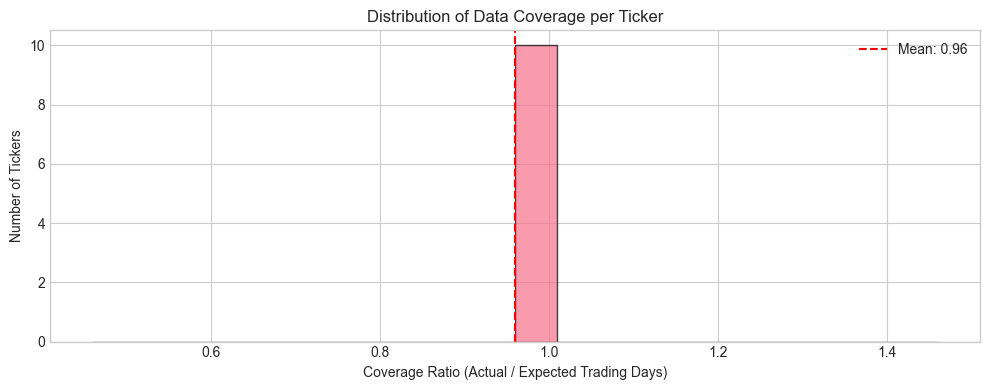

In [10]:
# Data Quality; Ticker-Level Coverage
ticker_summary = df.groupby('Ticker').agg(
    first_date=('Date', 'min'),
    last_date=('Date', 'max'),
    n_records=('Date', 'count'),
).reset_index()

# Expected trading days (roughly 252 / ann)
ticker_summary['years_span'] = (ticker_summary['last_date'] - ticker_summary['first_date']).dt.days / 365.25
ticker_summary['expected_records'] = (ticker_summary['years_span'] * 252).round().astype(int)
ticker_summary['coverage_ratio'] = ticker_summary['n_records'] / ticker_summary['expected_records']

print("Ticker-level coverage summary:")
print(ticker_summary.sort_values('n_records', ascending=False).to_string(index=False))

# Coverage histogram
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ticker_summary['coverage_ratio'].clip(0, 1), bins=20, edgecolor='black', alpha=0.7)
ax.set_xlabel('Coverage Ratio (Actual / Expected Trading Days)')
ax.set_ylabel('Number of Tickers')
ax.set_title('Distribution of Data Coverage per Ticker')
ax.axvline(ticker_summary['coverage_ratio'].mean(), color='red', linestyle='--', label=f'Mean: {ticker_summary["coverage_ratio"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# descriptive statistics; price and volume
print("=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

numeric_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
desc = df[numeric_cols].describe().T
desc['skewness'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurtosis()
print(desc.round(4))

DESCRIPTIVE STATISTICS
             count          mean           std   min       25%           50%  \
Open       10580.0  2.907630e+03  3.558901e+03  27.0     232.0  1.180000e+03   
High       10580.0  2.947949e+03  3.602894e+03  27.0     240.0  1.197252e+03   
Low        10580.0  2.866835e+03  3.513926e+03  27.0     226.0  1.155000e+03   
Close      10580.0  2.903808e+03  3.553677e+03  27.0     232.0  1.175000e+03   
Adj Close  10580.0  2.607942e+03  3.227371e+03  27.0     232.0  9.494814e+02   
Volume     10580.0  2.386281e+07  5.548417e+07   0.0  264900.0  3.162250e+06   

                    75%           max  skewness  kurtosis  
Open       4.080000e+03  1.455000e+04    1.2299    0.1576  
High       4.152500e+03  1.465000e+04    1.2352    0.1851  
Low        4.012500e+03  1.402500e+04    1.2230    0.1215  
Close      4.070000e+03  1.427500e+04    1.2277    0.1489  
Adj Close  3.796776e+03  1.387500e+04    1.2970    0.3838  
Volume     2.212130e+07  1.096103e+09    5.9701   59.074

Prices are heavily right skewed (skewness >> 0); typical for stock prices; suggests log transformation

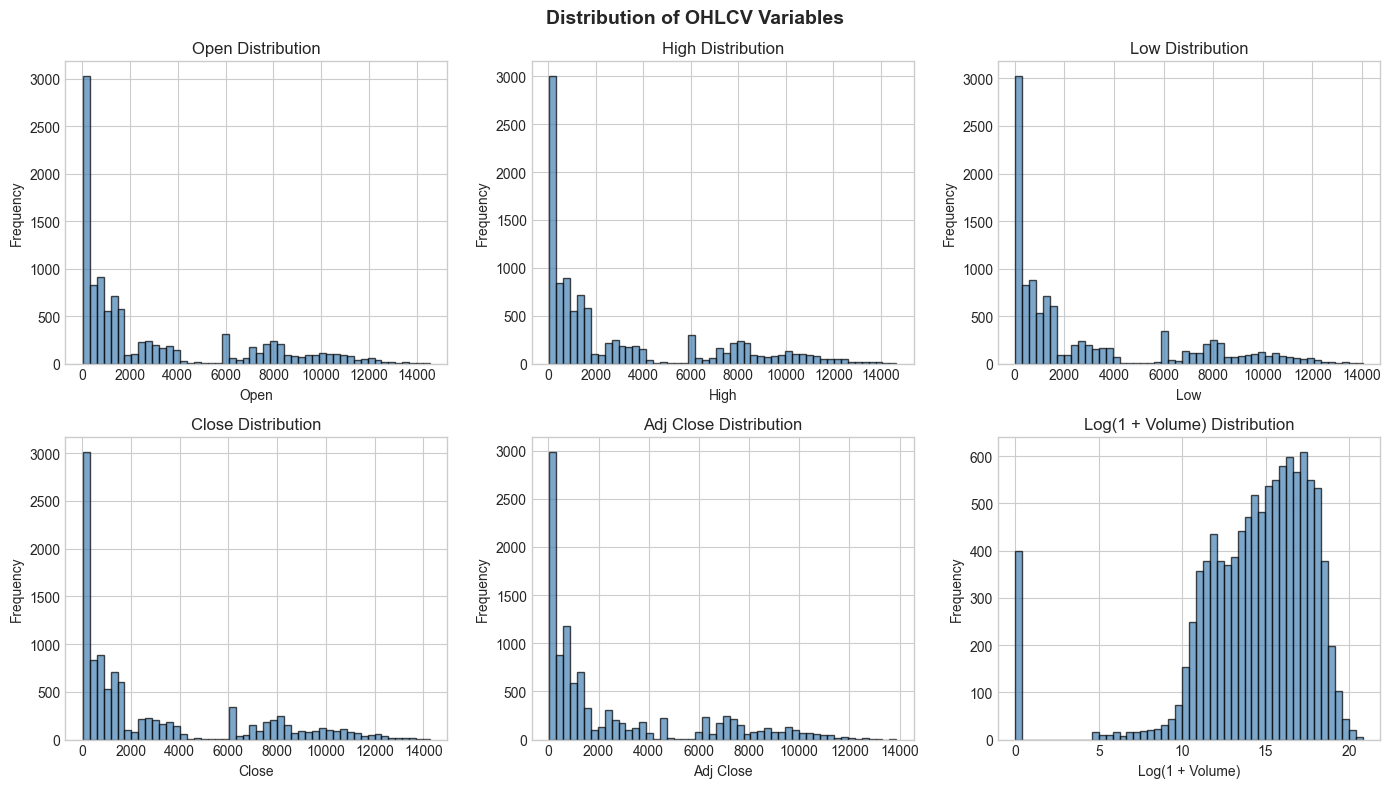

In [12]:
# dist visualizations
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    if col == 'Volume':
        data = np.log1p(df[col])
        ax.hist(data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        ax.set_title(f'Log(1 + {col}) Distribution')
        ax.set_xlabel(f'Log(1 + {col})')
    else:
        ax.hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        ax.set_title(f'{col} Distribution')
        ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.suptitle('Distribution of OHLCV Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

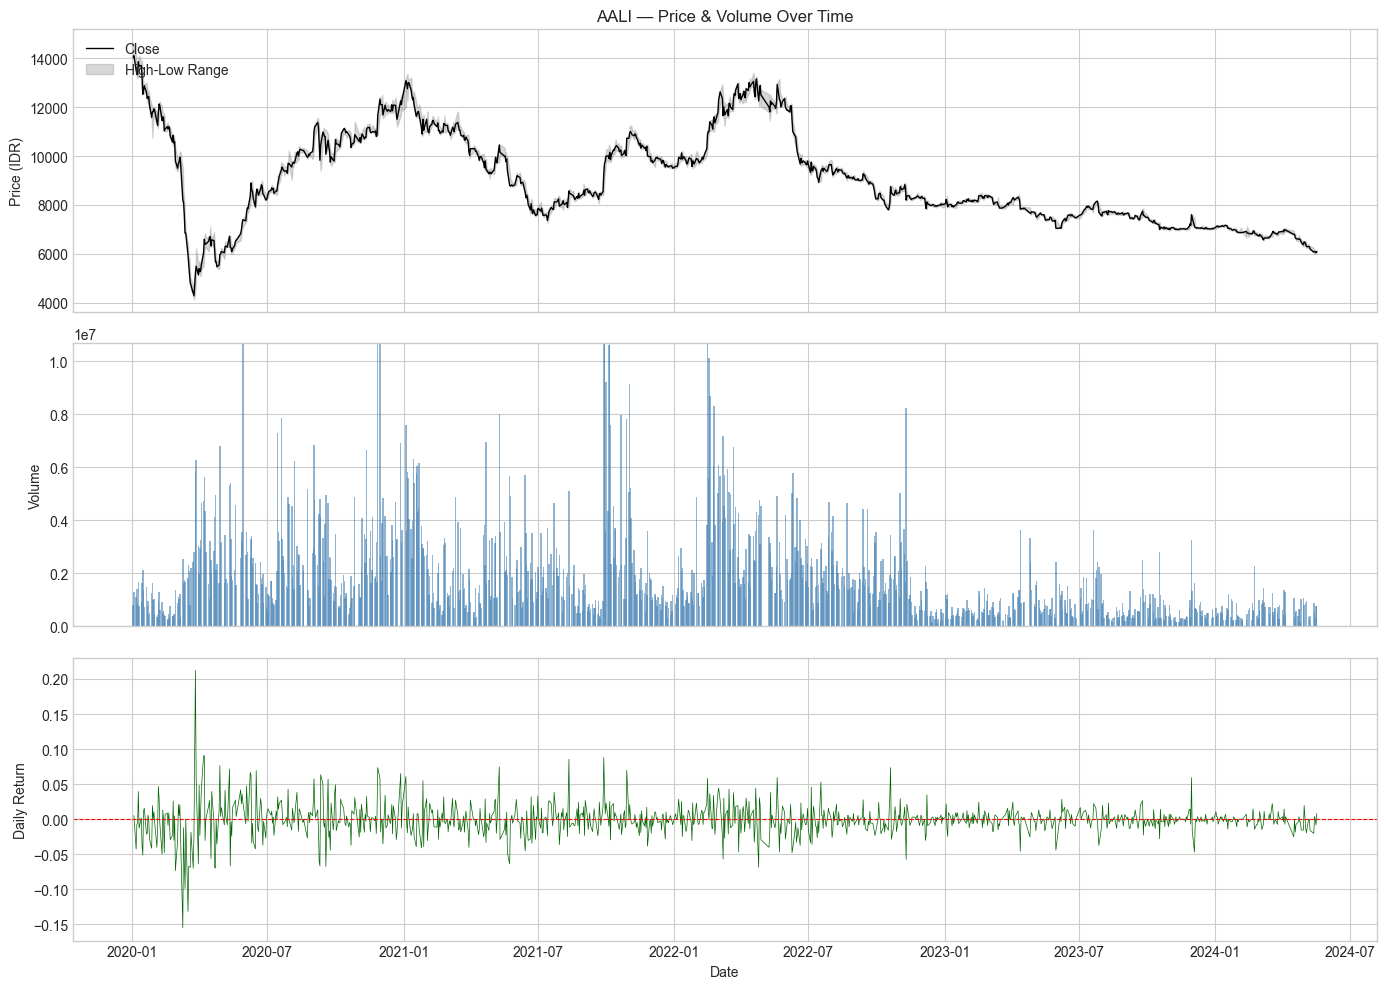


Sample ticker: AALI
Trading days: 1,058
Date range: 2020-01-02 to 2024-05-17


In [13]:
# Time Series Visualization w/ Sample Ticker
sample_ticker = selected_tickers[0]
sample_df = df[df['Ticker'] == sample_ticker].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(sample_df['Date'], sample_df['Close'], label='Close', color='black', linewidth=1)
axes[0].fill_between(sample_df['Date'], sample_df['Low'], sample_df['High'], alpha=0.3, color='gray', label='High-Low Range')
axes[0].set_ylabel('Price (IDR)')
axes[0].set_title(f'{sample_ticker} — Price & Volume Over Time')
axes[0].legend(loc='upper left')

axes[1].bar(sample_df['Date'], sample_df['Volume'], width=2, color='steelblue', alpha=0.6)
axes[1].set_ylabel('Volume')
axes[1].set_ylim(0, sample_df['Volume'].quantile(0.99) * 1.2)

sample_df['Daily_Return'] = sample_df['Close'].pct_change()
axes[2].plot(sample_df['Date'], sample_df['Daily_Return'], color='darkgreen', linewidth=0.5)
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=0.8)
axes[2].set_ylabel('Daily Return')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

print(f"\nSample ticker: {sample_ticker}")
print(f"Trading days: {len(sample_df):,}")
print(f"Date range: {sample_df['Date'].min().date()} to {sample_df['Date'].max().date()}")

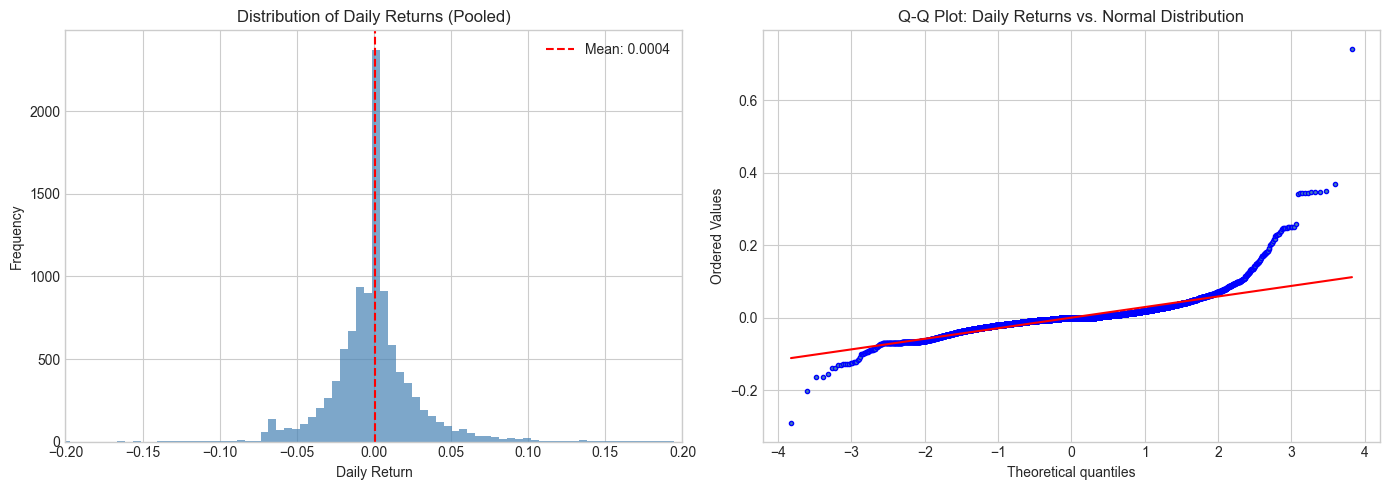


Returns Statistics:
  Mean:     0.000381
  Std Dev:  0.033175
  Skewness: 3.3420
  Kurtosis: 43.3554
  Min:      -0.2902
  Max:      0.7416


In [14]:
# Returns - dist and stationary
df['Daily_Return'] = df.groupby('Ticker')['Close'].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

returns = df['Daily_Return'].dropna()
axes[0].hist(returns, bins=200, edgecolor='none', alpha=0.7, color='steelblue')
axes[0].set_xlim(-0.2, 0.2)
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Daily Returns (Pooled)')
axes[0].axvline(returns.mean(), color='red', linestyle='--', label=f'Mean: {returns.mean():.4f}')
axes[0].legend()

stats.probplot(returns, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Daily Returns vs. Normal Distribution')
axes[1].get_lines()[0].set_markerfacecolor('steelblue')
axes[1].get_lines()[0].set_markersize(3)

plt.tight_layout()
plt.show()

print("\nReturns Statistics:")
print(f"  Mean:     {returns.mean():.6f}")
print(f"  Std Dev:  {returns.std():.6f}")
print(f"  Skewness: {returns.skew():.4f}")
print(f"  Kurtosis: {returns.kurtosis():.4f}")
print(f"  Min:      {returns.min():.4f}")
print(f"  Max:      {returns.max():.4f}")

Returns show fat tails --> high kurtosis; slight negative skewness

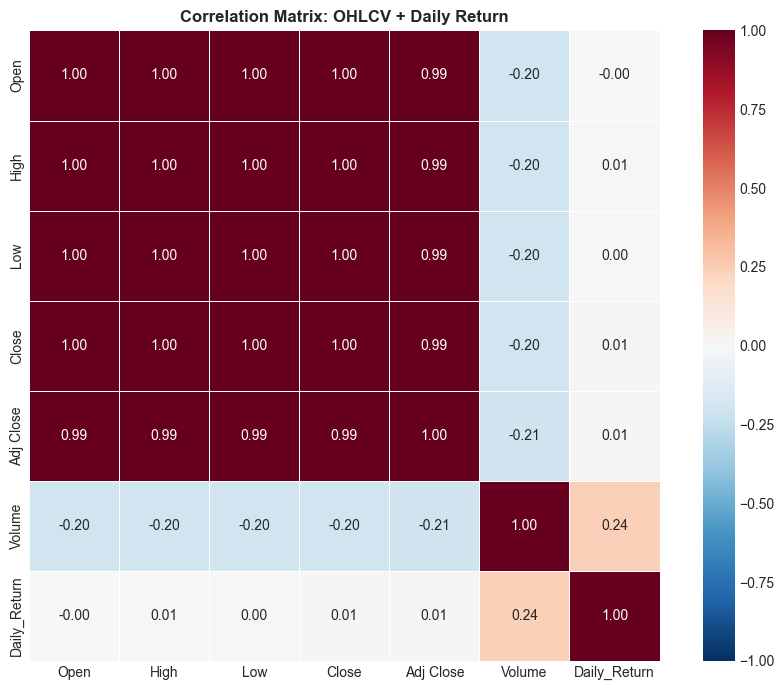

In [15]:
# Correlation — OHLCV Relationships
corr_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Daily_Return']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: OHLCV + Daily Return', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

OHLC are highly correlated; could imply the use of derived features

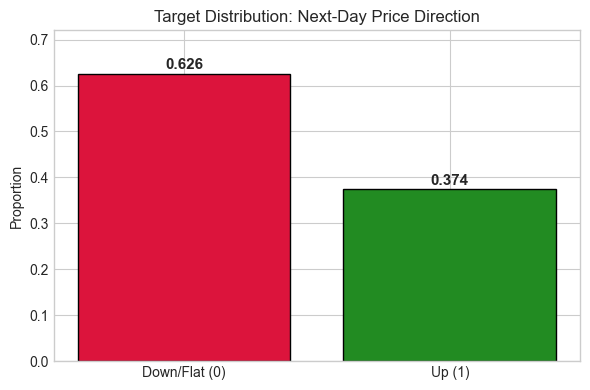


Target distribution:
  Down/Flat (0): 0.6261 (62.6%)
  Up (1):        0.3739 (37.4%)


In [16]:
# Target var (Next-Day Direction)
df['Target'] = df.groupby('Ticker')['Close'].shift(-1) > df['Close']
df['Target'] = df['Target'].astype(int)

target_dist = df['Target'].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Down/Flat (0)', 'Up (1)'], target_dist.values, color=['crimson', 'forestgreen'], edgecolor='black')
ax.set_ylabel('Proportion')
ax.set_title('Target Distribution: Next-Day Price Direction')
ax.set_ylim(0, target_dist.max() * 1.15)
for bar, val in zip(bars, target_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTarget distribution:")
print(f"  Down/Flat (0): {target_dist[0]:.4f} ({target_dist[0]*100:.1f}%)")
print(f"  Up (1):        {target_dist[1]:.4f} ({target_dist[1]*100:.1f}%)")


df = df.drop(columns=['Target'])

Target is moderately imbalanced 63/37
Down days outnumber up days (lol); majority class is 0
Consider class weights or stratified metrics.

In [17]:
# Trading day gap analysis
def analyze_gaps(group):
    group = group.sort_values('Date')
    gaps = group['Date'].diff().dt.days
    return pd.Series({
        'max_gap_days': gaps.max(),
        'avg_gap_days': gaps.mean(),
        'n_gaps_over_5': (gaps > 5).sum()
    })

gap_stats = df.groupby('Ticker').apply(analyze_gaps)

print("Trading Day Gap Statistics per Ticker:")
print(gap_stats.round(2))

Trading Day Gap Statistics per Ticker:
        max_gap_days  avg_gap_days  n_gaps_over_5
Ticker                                           
AALI            11.0          1.51            7.0
ABBA            11.0          1.51            7.0
ABMM            11.0          1.51            7.0
ACES            11.0          1.51            7.0
ACST            11.0          1.51            7.0
ADES            11.0          1.51            7.0
ADHI            11.0          1.51            7.0
ADMF            11.0          1.51            7.0
ADMG            11.0          1.51            7.0
ADRO            11.0          1.51            7.0


---

## End of Phase 2: EDA Summary

Before proceeding to **Phase 3 (Preprocessing)**, here are the key findings:

| Aspect | Finding | Implication |
|--------|---------|-------------|
| **Dataset scale** | ~millions of rows across hundreds of tickers (2020–2024) | Need memory-efficient chunked processing |
| **Missing data** | (see Cell 7) | Decide: drop, forward-fill, or interpolate |
| **Duplicates** | (see Cell 7) | Remove if any Date+Ticker duplicates exist |
| **Price skewness** | Heavily right-skewed | Use returns/ratios instead of raw prices |
| **Returns distribution** | Fat tails, slight negative skew | Rolling volatility is a valuable feature |
| **OHLC correlation** | >0.95 among price columns | Engineer uncorrelated features (ranges, returns) |
| **Target balance** | ~50/50 up/down | Accuracy is a valid primary metric |
| **Trading gaps** | Some tickers have extended gaps | Need careful handling for rolling window features |

### Action Items Before Phase 3:

1. **Obtain sector classification data** — The primary dataset lacks IDX-IC sector info. Download from one of:
   - [IDX Official Stock List](https://www.idx.co.id/en/market-data/stocks-data/stock-list/) (Download button → Excel with sector column)
   - [Kaggle: Indonesian Public Companies](https://www.kaggle.com/datasets/zororaka/indonesian-public-companies)
   - Join on `Ticker` column and document how unmatched tickers are handled.

2. **Select 2–3 IDX-IC sectors** — Per GOAL.md, choose sectors with ≤100 stocks total, roughly balanced across sectors. Document your criteria.

3. **Decide on preprocessing strategy:**
   - Minimum history threshold per ticker (e.g., 2+ years of data)?
   - How to handle trading gaps >5 days?
   - Feature lookback windows: 5-day, 10-day, 20-day, or multiple?
   - Adjusted Close vs Close for feature engineering?

4. **Define temporal split dates** — Train/validation/test must preserve time order:
   - Example: Train 2020-01 to 2022-12, Validation 2023-01 to 2023-12, Test 2024-01 to 2024-12

**Please review the EDA outputs above, obtain sector data, and let me know your preferences before I proceed to Phase 3.**

---

## Phase 3: Data Preparation — Sector Selection & Cleaned OHLCV Export


In [18]:
# Load and combine by sector
# each CSV in Dataset/stock-list-per-sector/ contains tickers for one
# IDX-IC sector. Combine them and cross-reference with the OHLCV dataset

import glob

SECTOR_DIR = os.path.join('Dataset', 'stock-list-per-sector')
sector_files = glob.glob(os.path.join(SECTOR_DIR, '*.csv'))

sector_dfs = []
for f in sorted(sector_files):
    basename = os.path.basename(f)
    # filename format: "Stock List  - {Sector} - YYYYMMDD.csv"
    sector_name = basename.split(' - ')[1].strip()
    df_s = pd.read_csv(f)
    df_s['Sector'] = sector_name
    sector_dfs.append(df_s[['Code', 'Sector']])

sector_df = pd.concat(sector_dfs, ignore_index=True)
sector_df = sector_df.rename(columns={'Code': 'Ticker'})

# Cross-reference with tickers present in the OHLCV dataset.
# unique_tickers is a set of 931 tickers from Cell 5 (scale overview).
sector_df = sector_df[sector_df['Ticker'].isin(unique_tickers)].copy()

print(f"Sector files loaded:          {len(sector_files)}")
print(f"Total sector-ticker entries:  {len(sector_df):,}")
print(f"Unique tickers matched:       {sector_df['Ticker'].nunique():,}")
print(f"Unique sectors:               {sector_df['Sector'].nunique()}")
print(f"\nTickers in OHLCV data but NOT in sector list: "
      f"{len(unique_tickers - set(sector_df['Ticker'])):,}")


Sector files loaded:          10
Total sector-ticker entries:  823
Unique tickers matched:       823
Unique sectors:               10

Tickers in OHLCV data but NOT in sector list: 108


In [19]:
sector_counts = sector_df['Sector'].value_counts().sort_values(ascending=False)

print("Sectors with active tickers in 2020-2024 OHLCV data:")
print("-" * 55)
for sector, count in sector_counts.items():
    bar = '#' * (count // 5)
    print(f"  {sector:<30} {count:>4} stocks  {bar}")

# --- select your sectors here ---
SELECTED_SECTORS = ['Energy', 'Technology']

selected_mask = sector_df['Sector'].isin(SELECTED_SECTORS)
SELECTED_MODEL_TICKERS = sector_df[selected_mask]['Ticker'].tolist()

print(f"\nSelected sectors: {SELECTED_SECTORS}")
print(f"Total stocks in selected sectors: {len(SELECTED_MODEL_TICKERS)}")
for s in SELECTED_SECTORS:
    n = sector_df[sector_df['Sector'] == s].shape[0]
    print(f"  {s}: {n} stocks")


Sectors with active tickers in 2020-2024 OHLCV data:
-------------------------------------------------------
  Consumer Cyclicals              154 stocks  ##############################
  Consumer Non-Cyclicals          125 stocks  #########################
  Basic Materials                 105 stocks  #####################
  Financials                      103 stocks  ####################
  Energy                           87 stocks  #################
  Infrastructures                  68 stocks  #############
  Industrials                      64 stocks  ############
  Technology                       47 stocks  #########
  Transportation & Logistic        37 stocks  #######
  Healthcare                       33 stocks  ######

Selected sectors: ['Energy', 'Technology']
Total stocks in selected sectors: 134
  Energy: 87 stocks
  Technology: 47 stocks


In [20]:
# Remove Suspended Stocks from Selected Tickers
from collections import defaultdict

print(f"Before suspended filter: {len(SELECTED_MODEL_TICKERS)} tickers")
print("Checking Close price quality on selected tickers...")

close_vals = defaultdict(list)
for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE,
                         usecols=['Date', 'Ticker', 'Close']):
    chunk['Date'] = pd.to_datetime(chunk['Date'])
    mask = (chunk['Date'] >= START_DATE) & (chunk['Date'] <= END_DATE)
    mask &= chunk['Ticker'].isin(SELECTED_MODEL_TICKERS)
    chunk = chunk[mask]
    if len(chunk) == 0:
        continue
    for ticker in chunk['Ticker'].unique():
        sub = chunk[chunk['Ticker'] == ticker]
        close_vals[ticker].append(sub['Close'].values)

suspended_in_selection = []
for ticker in SELECTED_MODEL_TICKERS:
    if ticker in close_vals:
        all_close = np.concatenate(close_vals[ticker])
        if np.nanstd(all_close) == 0:
            suspended_in_selection.append(ticker)
    else:
        suspended_in_selection.append(ticker)  # no data at all

if suspended_in_selection:
    print(f"Removing {len(suspended_in_selection)} suspended: "
          f"{suspended_in_selection}")
    SELECTED_MODEL_TICKERS = [t for t in SELECTED_MODEL_TICKERS
                              if t not in suspended_in_selection]
else:
    print("No suspended tickers found.")

print(f"After suspended filter:  {len(SELECTED_MODEL_TICKERS)} tickers")
print(f"Final tickers: {SELECTED_MODEL_TICKERS}")


Before suspended filter: 134 tickers
Checking Close price quality on selected tickers...
Removing 4 suspended: ['MTFN', 'SMRU', 'SUGI', 'TRAM']
After suspended filter:  130 tickers
Final tickers: ['ABMM', 'AKRA', 'APEX', 'ARII', 'ARTI', 'BBRM', 'BIPI', 'BSSR', 'BULL', 'BUMI', 'BYAN', 'CANI', 'CNKO', 'DEWA', 'DOID', 'DSSA', 'ELSA', 'ENRG', 'GEMS', 'GTBO', 'HITS', 'HRUM', 'IATA', 'INDY', 'ITMA', 'ITMG', 'KKGI', 'KOPI', 'LEAD', 'MBAP', 'MBSS', 'MEDC', 'MYOH', 'PGAS', 'PKPK', 'PTBA', 'PTIS', 'PTRO', 'RAJA', 'RIGS', 'RUIS', 'SMMT', 'SOCI', 'TOBA', 'TPMA', 'WINS', 'SHIP', 'TAMU', 'FIRE', 'PSSI', 'DWGL', 'BOSS', 'JSKY', 'INPS', 'TCPI', 'SURE', 'WOWS', 'TEBE', 'SGER', 'UNIQ', 'MCOL', 'GTSI', 'RMKE', 'BSML', 'ADMR', 'SEMA', 'SICO', 'COAL', 'SUNI', 'CBRE', 'HILL', 'CUAN', 'MAHA', 'RMKO', 'HUMI', 'RGAS', 'ALII', 'MKAP', 'ATLA', 'BESS', 'CGAS', 'ADRO', 'AIMS', 'ATIC', 'EMTK', 'KREN', 'LMAS', 'MLPT', 'MTDL', 'PTSN', 'SKYB', 'KIOS', 'MCAS', 'NFCX', 'DIVA', 'LUCK', 'ENVY', 'HDIT', 'TFAS', 'DMMX', 'GL

In [21]:
# Load Full OHLCV Data for Selected Sectors
print(f"Loading full OHLCV data for {len(SELECTED_MODEL_TICKERS)} tickers...")

dfs_all = []
for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE):
    chunk['Date'] = pd.to_datetime(chunk['Date'])
    date_mask = (chunk['Date'] >= START_DATE) & (chunk['Date'] <= END_DATE)
    ticker_mask = chunk['Ticker'].isin(SELECTED_MODEL_TICKERS)
    chunk = chunk[date_mask & ticker_mask]
    if len(chunk) == 0:
        continue
    dfs_all.append(chunk)

df_model = pd.concat(dfs_all, ignore_index=True)
df_model = df_model.sort_values(['Ticker', 'Date']).reset_index(drop=True)

# Attach sector label to each row
ticker_to_sector = dict(zip(sector_df['Ticker'], sector_df['Sector']))
df_model['sector'] = df_model['Ticker'].map(ticker_to_sector)

print(f"Loaded {len(df_model):,} rows for {df_model['Ticker'].nunique()} tickers")
print(f"Date range: {df_model['Date'].min().date()} to {df_model['Date'].max().date()}")
print(f"Sectors: {df_model['sector'].unique()}")
print(f"\nRecords per ticker: min={df_model.groupby('Ticker').size().min()}, "
      f"median={df_model.groupby('Ticker').size().median():.0f}, "
      f"max={df_model.groupby('Ticker').size().max()}")


Loading full OHLCV data for 130 tickers...
Loaded 105,236 rows for 130 tickers
Date range: 2020-01-02 to 2024-05-17
Sectors: <ArrowStringArray>
['Energy', 'Technology']
Length: 2, dtype: str

Records per ticker: min=21, median=1058, max=1058


In [22]:
# Data Cleaning
print(f"Before cleaning: {len(df_model):,} rows")

# Forward-fill missing OHLCV within each ticker (limit=3 to avoid over-filling gaps)
ohlcv_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
df_model[ohlcv_cols] = df_model.groupby('Ticker')[ohlcv_cols].transform(
    lambda g: g.ffill(limit=3)
)

# Drop rows where Close is still NaN after forward-fill
before = len(df_model)
df_model = df_model.dropna(subset=['Close'])
print(f"Dropped {before - len(df_model):,} rows with NaN Close")

# Remove non-trading days (zero volume AND flat OHLC)
df_model['_flat'] = (df_model['High'] == df_model['Low']) & (df_model['Volume'] == 0)
n_flat = df_model['_flat'].sum()
df_model = df_model[~df_model['_flat']].drop(columns=['_flat'])
print(f"Removed {n_flat:,} zero-volume flat-price rows")

print(f"After cleaning: {len(df_model):,} rows")
print(f"Missing values remaining:")
print(df_model[ohlcv_cols].isnull().sum())


Before cleaning: 105,236 rows
Dropped 0 rows with NaN Close
Removed 9,304 zero-volume flat-price rows
After cleaning: 95,932 rows
Missing values remaining:
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [25]:
# Preview cleaned data before export
print(f"Cleaned data shape: {df_model.shape[0]:,} rows x {df_model.shape[1]} columns")
print(f"Columns: {list(df_model.columns)}")
print(f"Data types:")
print(df_model.dtypes)
print(f"Descriptive statistics (numeric columns):")
display(df_model.describe())


Cleaned data shape: 95,932 rows x 9 columns
Columns: ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'sector']
Data types:
Date         datetime64[us]
Ticker                  str
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume              float64
sector                  str
dtype: object
Descriptive statistics (numeric columns):


,Date,Open,High,Low,Close,Adj Close,Volume
count,95932,95932.000000,95932.000000,95932.000000,95932.000000,95932.000000,9.593200e+04
mean,2022-05-23 19:55:30.409039,1768.183191,1802.005910,1737.301416,1770.644404,1624.793873,5.709491e+07
min,2020-01-02 00:00:00,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000e+00
25%,2021-05-20 00:00:00,141.000000,146.000000,137.000000,141.000000,139.000000,1.027000e+05
50%,2022-06-30 00:00:00,345.396820,354.000000,336.000000,344.000000,330.000000,1.640800e+06
75%,2023-06-26 00:00:00,1190.000000,1215.000000,1160.000000,1190.000000,1064.818604,1.673460e+07
max,2024-05-17 00:00:00,148000.000000,163000.000000,147700.000000,147975.000000,147975.000000,6.601081e+10
std,NaN,5749.069504,5849.699652,5687.559082,5779.526332,5495.453819,4.784653e+08


---

## End of Phase 3

The cleaned OHLCV dataset is exported below.


In [26]:
# Export Cleaned OHLCV Dataset
OUTPUT_PATH = os.path.join("Dataset", "cleaned_data.csv")

export_cols = ["Date", "Ticker", "Open", "High", "Low", "Close", "Adj Close", "Volume", "sector"]
df_model[export_cols].to_csv(OUTPUT_PATH, index=False)

file_mb = os.path.getsize(OUTPUT_PATH) / (1024**2)
print(f"Saved: {OUTPUT_PATH}")
print(f"Shape: {len(df_model):,} rows x {len(export_cols)} columns")
print(f"File size: {file_mb:.1f} MB")


Saved: Dataset\cleaned_data.csv
Shape: 95,932 rows x 9 columns
File size: 6.2 MB


In [30]:
print(f"Tickers:           {df_model["Ticker"].nunique()}")
print(f"Total rows:        {len(df_model):,}")
print(f"Date range:        {df_model["Date"].min().date()} to {df_model["Date"].max().date()}")
print(f"Sectors:           {list(df_model["sector"].unique())}")
print(f"Sector distribution:")
print(df_model["sector"].value_counts())
print(f"Rows per ticker: min={df_model.groupby("Ticker").size().min()}, "
      f"median={df_model.groupby("Ticker").size().median():.0f}, "
      f"max={df_model.groupby("Ticker").size().max()}")
print(f"Missing values:")
print(df_model.isnull().sum())


Tickers:           130
Total rows:        95,932
Date range:        2020-01-02 to 2024-05-17
Sectors:           ['Energy', 'Technology']
Sector distribution:
sector
Energy        66885
Technology    29047
Name: count, dtype: int64
Rows per ticker: min=21, median=958, max=1058
Missing values:
Date         0
Ticker       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
sector       0
dtype: int64
